# Lab: Principal Component Analysis

---

Throughout this specialization, we've worked extensively with the Iris dataset—applying supervised learning algorithms like Logistic Regression and Decision Trees. In this lab, we shift our focus to **dimensionality reduction** using Principal Component Analysis (PCA). 

Rather than building predictive models, our goal is to practice applying PCA for feature extraction and to learn how to determine the optimal number of principal components. 

By the end of this lab, you'll understand how to reduce the Iris dataset's four features into a lower-dimensional space while preserving the most important information, and how to use **explained variance** as a guide for selecting the right number of components.

---

## Data Collection
Let's start with importing the necessary libraries and loading the Iris dataset!

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Configurations
plt.style.use("fivethirtyeight")
sns.set_theme(style="white", palette="colorblind")

In [25]:
# Load iris dataset and create DataFrame
iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target_names[iris.target]
iris_df.sample(5, random_state=42)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
73,6.1,2.8,4.7,1.2,versicolor
18,5.7,3.8,1.7,0.3,setosa
118,7.7,2.6,6.9,2.3,virginica
78,6.0,2.9,4.5,1.5,versicolor
76,6.8,2.8,4.8,1.4,versicolor



---

## Data Preparation
Since PCA is sensitive to the scale of the data, we'll also standardize the features before applying PCA. 

In [26]:
X = iris_df.drop(columns=['target'])
y = iris_df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


---

## Modeling and Evaluation

Now we can apply PCA to the standardized data. We'll start by fitting PCA without specifying the number of components, allowing us to analyze the explained variance later.

In [27]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

We’ll inspect the per-component and cumulative explained variance to decide how many principal components are worth keeping.

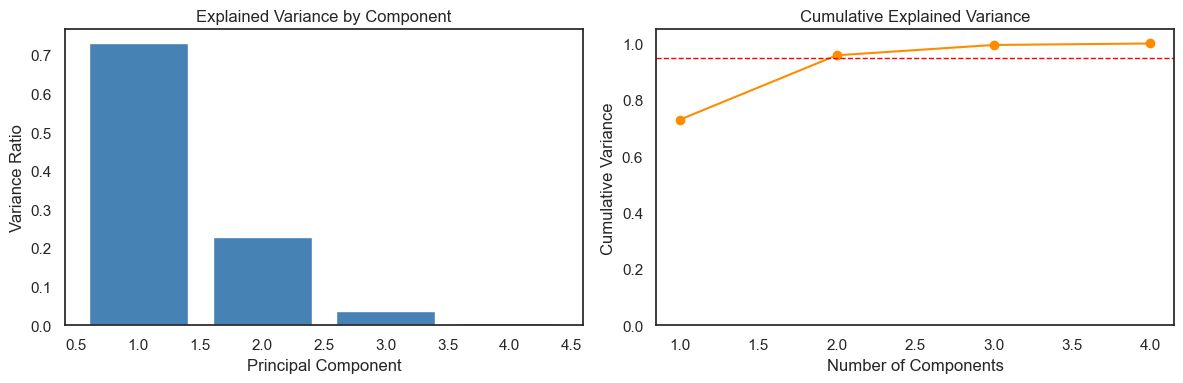

In [28]:
explained_var = pca.explained_variance_ratio_
cum_explained = explained_var.cumsum()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(range(1, len(explained_var)+1), explained_var, color='steelblue')
ax[0].set_title('Explained Variance by Component')
ax[0].set_xlabel('Principal Component')
ax[0].set_ylabel('Variance Ratio')

ax[1].plot(range(1, len(cum_explained)+1), cum_explained, marker='o', color='darkorange')
ax[1].axhline(0.95, color='red', ls='--', lw=1)
ax[1].set_title('Cumulative Explained Variance')
ax[1].set_xlabel('Number of Components')
ax[1].set_ylabel('Cumulative Variance')
ax[1].set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

The cumulative variance curve shows a clear elbow at **2 components**, capturing the majority of the information in the Iris features. Selecting two principal components is a sensible default for this dataset, balancing dimensionality reduction with information retention.

Next, let’s visualize the first two principal components, coloring points by species to see how well PCA separates the classes.

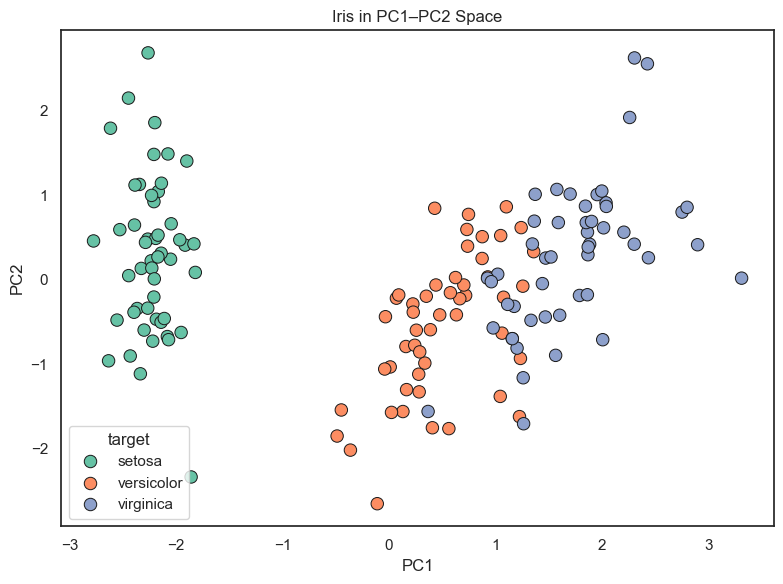

In [29]:
pc_df = pd.DataFrame(X_pca[:, :2], columns=['PC1', 'PC2'])
pc_df['target'] = y

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pc_df, x='PC1', y='PC2', hue='target', palette='Set2', s=80, edgecolor='k')
plt.title('Iris in PC1–PC2 Space')
plt.tight_layout()
plt.show()

With just the first two components, **setosa** is cleanly separated by eye. The other two species (versicolor and virginica) overlap, so distinguishing them would require a decision boundary—e.g., a distance-based method (k-NN) or a density/large-margin approach (DBSCAN, SVM) as we've done before.

---

**Next:** []()